# EDA — `transactions`, full history: can last-payment dates reveal delinquency?

**Hypothesis to test.** Unify all transactions since 2023, take the **last approved `Payment` per
product**, and compute `today - last payment date`. If that recovers delinquency (and the payments
made *after* a delinquency starts), we would have a payment-based target that `products.csv` lacks.

We already know from June alone (`transactions.ipynb`) that `Payment` is not tied to any obligation.
This notebook tests the hypothesis on the **whole history** (1,097 daily files) instead.

**Memory-safe by design.** The raw files are ~0.75 GB of CSV, more than is comfortable to load
at once. The notebook therefore processes **one daily file at a time**, reads only five columns, and
keeps only the approved `Payment` rows (as an integer product code and a date) plus per-file counts
and a hash of each `transaction_id` (for a duplicate check). Nothing else is retained. The process
memory is measured below.

Scope: descriptive only, no model. Delinquency labels come from the `products.csv` snapshot.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
PRODUCTS_PATH = REPO_ROOT / "data" / "data" / "products.csv"
TRANSACTIONS_ROOT = REPO_ROOT / "data" / "transactions"

TRANSACTION_COLUMNS = ["transaction_id", "transaction_date", "product_id", "transaction_type", "transaction_status"]
BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"

products = pd.read_csv(
    PRODUCTS_PATH,
    usecols=["product_id", "product_type", "product_status", "days_past_due", "opening_date", "last_transaction_date"],
    parse_dates=["opening_date", "last_transaction_date"],
)
REFERENCE_DATE = products["last_transaction_date"].max().normalize()
product_index = pd.Index(products["product_id"])
products["product_code"] = np.arange(len(products), dtype="int32")
products = products.drop(columns="last_transaction_date")

def current_memory_mb() -> float:
    """Measures the resident memory of this notebook's process.

    Exists to prove the streaming approach stays small on a machine with limited free RAM.

    Args:
        None.

    Returns:
        float: resident set size in megabytes.
    """
    return psutil.Process().memory_info().rss / 1e6


memory_start_mb = current_memory_mb()
REFERENCE_DATE, memory_start_mb

(Timestamp('2026-06-17 00:00:00'), 189.149184)

## 2. Stream all daily files

In [2]:
def summarize_partition(path: Path, product_index: pd.Index) -> tuple[dict, pd.DataFrame, np.ndarray]:
    """Reduces one daily transaction file to counts, its approved payments and id hashes.

    Exists so the full history can be scanned one file at a time without ever holding all
    transactions in memory.

    Args:
        path: Path of one `transactions_YYYYMMDD.csv` file inside a year/month/day partition.
        product_index: Index of every product_id in products.csv, used to encode product ids as integers.

    Returns:
        tuple: (per-file counts, approved payments as product_code and payment_date, uint64 hashes of transaction_id).
        payment_date is the partition's business day (process date), not the raw timestamp's calendar day.
    """
    frame = pd.read_csv(path, usecols=TRANSACTION_COLUMNS, dtype=str)
    partition_date = f"{path.parents[2].name[5:]}-{path.parents[1].name[6:]}-{path.parent.name[4:]}"
    product_codes = product_index.get_indexer(frame["product_id"])
    is_approved_payment = (frame["transaction_type"] == "Payment") & (frame["transaction_status"] == "Approved")
    business_day = (pd.to_datetime(frame["transaction_date"]) - pd.Timedelta(hours=6)).dt.strftime("%Y-%m-%d")
    payments = pd.DataFrame({
        "product_code": product_codes[is_approved_payment.to_numpy()].astype("int32"),
        "payment_date": np.full(int(is_approved_payment.sum()), np.datetime64(partition_date, "ns")),
    })
    counts = {
        "partition_date": partition_date,
        "rows": len(frame),
        "rows_dated_outside_partition": int((frame["transaction_date"].str[:10] != partition_date).sum()),
        "rows_breaking_business_day_rule": int((business_day != partition_date).sum()),
        "rows_with_unknown_product": int((product_codes < 0).sum()),
        "approved_payments": int(is_approved_payment.sum()),
    }
    return counts, payments, pd.util.hash_array(frame["transaction_id"].to_numpy())


partition_files = sorted(TRANSACTIONS_ROOT.glob("year=*/month=*/day=*/transactions_*.csv"))
file_counts, payment_frames, id_hash_chunks = [], [], []
peak_memory_mb = memory_start_mb
for path in partition_files:
    counts, payments, hashes = summarize_partition(path, product_index)
    file_counts.append(counts)
    payment_frames.append(payments)
    id_hash_chunks.append(hashes)
    peak_memory_mb = max(peak_memory_mb, current_memory_mb())

file_counts = pd.DataFrame(file_counts)
file_counts["partition_date"] = pd.to_datetime(file_counts["partition_date"])
approved_payments = pd.concat(payment_frames, ignore_index=True)
all_id_hashes = np.concatenate(id_hash_chunks)
del payment_frames, id_hash_chunks
len(partition_files), len(approved_payments)

(1097, 679954)

### What was read, and what it cost in memory

In [3]:
calendar_days = pd.date_range(file_counts["partition_date"].min(), file_counts["partition_date"].max())
display(pd.Series({
    "daily files read": len(file_counts),
    "first / last partition date": f"{file_counts['partition_date'].min().date()} / {file_counts['partition_date'].max().date()}",
    "calendar days without a file in that range": len(calendar_days.difference(file_counts["partition_date"])),
    "transactions": file_counts["rows"].sum(),
    "duplicate transaction_id (hash-based, all files)": len(all_id_hashes) - len(np.unique(all_id_hashes)),
    "rows whose timestamp date differs from their partition day": file_counts["rows_dated_outside_partition"].sum(),
    "rows breaking the rule 'partition day = (timestamp - 6 hours).date'": file_counts["rows_breaking_business_day_rule"].sum(),
    "rows whose product_id is not in products.csv": file_counts["rows_with_unknown_product"].sum(),
    "approved Payment rows kept": len(approved_payments),
    "kept payments, MB in memory": approved_payments.memory_usage(deep=True).sum() / 1e6,
    "process memory at start, MB": memory_start_mb,
    "peak process memory while streaming, MB": peak_memory_mb,
}, name="value").to_frame())
display(file_counts.groupby(file_counts["partition_date"].dt.to_period("M"))["rows"].sum().to_frame("transactions per month").T)

,value
daily files read,1097
first / last partition date,2023-06-17 / 2026-06-17
calendar days without a file in that range,0
transactions,4425008
"duplicate transaction_id (hash-based, all files)",0
rows whose timestamp date differs from their partition day,1106307
rows breaking the rule 'partition day = (timestamp - 6 hours).date',51
rows whose product_id is not in products.csv,0
approved Payment rows kept,679954
"kept payments, MB in memory",8.16


partition_date,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
transactions per month,57418,121121,127919,118902,128065,122255,125490,122418,117330,121105,121731,126416,121441,129316,122109,118012,127758,120835,123343,122056,110632,123365,120838,126679,118998,126867,125886,118785,129256,120323,122817,121549,115332,124296,126499,127155,70691


**Partitions follow the business day, not the calendar day.** A quarter of the rows carry a timestamp
whose calendar date differs from their partition, yet only 51 of 4.4 million rows break the rule
`partition day = (timestamp - 6 hours).date`: the day cuts over at 06:00. That is a consistent
accounting-day convention, not an error, so payment dates below use the business day (the partition).

Only about the size of the payments table (a few MB) is retained beyond the small products table.
The streaming loop keeps the process far below the free memory, and never holds more than one
daily file.

## 3. Payments per credit product

In [4]:
credit = products[products["days_past_due"].notna()].copy()
credit["is_delinquent"] = credit["days_past_due"] > 0
active_credit = credit[credit["product_status"] == "Active"].copy()

payments_up_to_reference = approved_payments[approved_payments["payment_date"] <= REFERENCE_DATE]
credit_payments = payments_up_to_reference[payments_up_to_reference["product_code"].isin(active_credit["product_code"])]
opening_by_code = products.set_index("product_code")["opening_date"]

display(pd.Series({
    "Active credit products": len(active_credit),
    "approved payments on them up to the reference date": len(credit_payments),
    "approved payments after the reference date (excluded)": len(approved_payments) - len(payments_up_to_reference),
    "payments dated before the product's opening_date (any product)":
        (approved_payments["payment_date"] < approved_payments["product_code"].map(opening_by_code)).sum(),
}, name="value").to_frame())

per_product = credit_payments.groupby("product_code")["payment_date"].agg(payments="size", first_payment="min", last_payment="max")
active_credit = active_credit.merge(per_product, on="product_code", how="left")
active_credit["payments"] = active_credit["payments"].fillna(0).astype(int)
active_credit["days_since_last_payment"] = (REFERENCE_DATE - active_credit["last_payment"]).dt.days

display(active_credit["payments"].clip(upper=6).value_counts().sort_index().to_frame("products").rename_axis("payments in history (6 = 6+)"))
display(active_credit["days_since_last_payment"].describe().to_frame())

,value
Active credit products,106596
approved payments on them up to the reference date,330146
approved payments after the reference date (excluded),0
payments dated before the product's opening_date (any product),128092


,products
payments in history (6 = 6+),
0,13372
1,24281
2,22307
3,13972
4,8010
5,5202
6,19452


,days_since_last_payment
count,"93,224.00"
mean,324.47
std,282.80
min,0.00
25%,91.00
50%,238.00
75%,497.00
max,"1,096.00"


### Do payments follow a cadence (instalments)?

If payments were instalments on a credit obligation, gaps between consecutive payments on the same
product would cluster around a regular interval (typically ~30 days).

,"days between consecutive payments, same product"
count,"236,922.00"
mean,175.23
std,176.08
min,0.00
10%,17.00
25%,48.00
50%,117.00
75%,243.00
90%,419.00
max,"1,088.00"


,value
gaps between consecutive payments,"236,922.00"
share of gaps between 25 and 35 days (observed),5.51
share of gaps between 25 and 35 days if payments arrived at random (same mean gap),5.28
share of gaps between 55 and 65 days (observed),4.56
share of gaps between 55 and 65 days if payments arrived at random (same mean gap),4.45


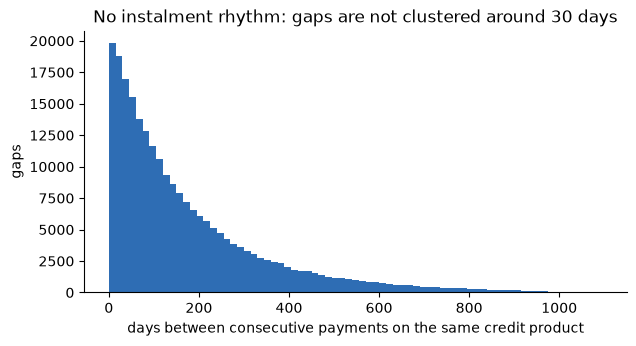

In [5]:
ordered_payments = credit_payments.sort_values(["product_code", "payment_date"])
gap_days = ordered_payments.groupby("product_code")["payment_date"].diff().dt.days.dropna()

display(gap_days.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("days between consecutive payments, same product"))
mean_gap_days = gap_days.mean()
display(pd.Series({
    "gaps between consecutive payments": len(gap_days),
    "share of gaps between 25 and 35 days (observed)": ((gap_days >= 25) & (gap_days <= 35)).mean() * 100,
    "share of gaps between 25 and 35 days if payments arrived at random (same mean gap)":
        (np.exp(-25 / mean_gap_days) - np.exp(-36 / mean_gap_days)) * 100,
    "share of gaps between 55 and 65 days (observed)": ((gap_days >= 55) & (gap_days <= 65)).mean() * 100,
    "share of gaps between 55 and 65 days if payments arrived at random (same mean gap)":
        (np.exp(-55 / mean_gap_days) - np.exp(-66 / mean_gap_days)) * 100,
}, name="value").to_frame())

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(gap_days, bins=range(0, int(gap_days.max()) + 15, 15), color=BAR_COLOR)
ax.set_xlabel("days between consecutive payments on the same credit product")
ax.set_ylabel("gaps")
ax.set_title("No instalment rhythm: gaps are not clustered around 30 days")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. Days since last payment vs `days_past_due`

In [6]:
by_days_past_due = active_credit.groupby("days_past_due").agg(
    products=("product_id", "size"),
    with_a_payment_pct=("payments", lambda s: (s > 0).mean() * 100),
    median_days_since_last_payment=("days_since_last_payment", "median"),
    mean_payments=("payments", "mean"),
)
display(by_days_past_due)

payers = active_credit.dropna(subset=["days_since_last_payment"])
delinquent_payers = payers[payers["is_delinquent"]]
display(pd.Series({
    "Spearman: days_past_due vs days since last payment (products with a payment)":
        payers["days_past_due"].rank().corr(payers["days_since_last_payment"].rank()),
    "delinquent products with a payment AFTER the implied start (days since last payment < days_past_due), %":
        (delinquent_payers["days_since_last_payment"] < delinquent_payers["days_past_due"]).mean() * 100,
}, name="value").to_frame())

recency_bucket = pd.cut(
    active_credit["days_since_last_payment"], [-1, 30, 90, 180, 365, 10000],
    labels=["0-30", "31-90", "91-180", "181-365", "366+"],
).astype(str).where(active_credit["last_payment"].notna(), "never paid")
recency_rates = active_credit["is_delinquent"].groupby(recency_bucket).agg(delinquent_rate="mean", products="size")
recency_rates["delinquent_rate"] *= 100
recency_rates["ci_half_width_pct"] = 196 * (recency_rates["delinquent_rate"] / 100 * (1 - recency_rates["delinquent_rate"] / 100) / recency_rates["products"]) ** 0.5
display(recency_rates.loc[["0-30", "31-90", "91-180", "181-365", "366+", "never paid"]])

,products,with_a_payment_pct,median_days_since_last_payment,mean_payments
days_past_due,,,,
0.00,90707,87.45,238.00,3.10
15.00,2647,86.74,243.50,3.05
30.00,2620,86.98,232.00,3.14
60.00,2648,87.88,253.00,3.01
90.00,2724,87.81,222.00,3.13
120.00,2600,87.92,248.00,3.10
180.00,2650,87.74,230.00,3.14


,value
Spearman: days_past_due vs days since last payment (products with a payment),0.00
"delinquent products with a payment AFTER the implied start (days since last payment < days_past_due), %",21.19


,delinquent_rate,products,ci_half_width_pct
days_since_last_payment,,,
0-30,14.64,9123,0.73
31-90,14.81,14081,0.59
91-180,15.12,15525,0.56
181-365,14.90,21200,0.48
366+,14.95,33295,0.38
never paid,14.84,13372,0.60


### The delinquent-vs-current view

If a long time since the last payment marked delinquency, delinquent products would show larger
`days_since_last_payment` than current ones, rising with `days_past_due`.

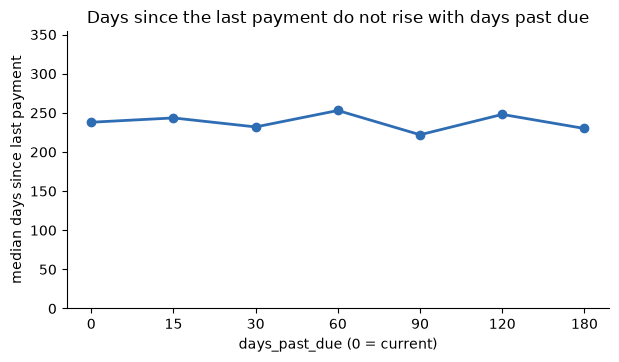

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
positions = range(len(by_days_past_due))
ax.plot(list(positions), by_days_past_due["median_days_since_last_payment"], "o-", color=BAR_COLOR, linewidth=2)
ax.set_xticks(list(positions))
ax.set_xticklabels(by_days_past_due.index.astype(int).astype(str))
ax.set_xlabel("days_past_due (0 = current)")
ax.set_ylabel("median days since last payment")
ax.set_ylim(0, max(by_days_past_due["median_days_since_last_payment"]) * 1.4)
ax.set_title("Days since the last payment do not rise with days past due")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 5. Payments after delinquency starts (and before)

If `days_past_due = d` on the snapshot date, the implied delinquency began `d` days earlier.
Two tests, each against **current products** (`days_past_due = 0`) used over the same windows as a
control, restricted to products already open before the earliest window used:

- **After:** share of products with at least one approved payment in `[snapshot - d, snapshot)`,
  the `d` business days before the snapshot day.
  If delinquent products were being worked, or paying while late, this would differ from the control.
- **Before:** the same share in the equally long window just before (`[snapshot - 2d, snapshot - d)`).
  If delinquency began because payments stopped, delinquent products would show a drop from *before*
  to *after* that current products do not.

In [8]:
def has_payment_in_window(product_codes: pd.Series, start: pd.Timestamp, end: pd.Timestamp) -> np.ndarray:
    """Flags which products have at least one approved payment in a date window.

    Exists so the same window logic is applied to delinquent and control products, and so before/after
    flags can be compared product by product.

    Args:
        product_codes: Integer product codes of the products being measured.
        start: First day of the window (inclusive).
        end: Day after the last day of the window (exclusive).

    Returns:
        np.ndarray: boolean flag per product, in the order of product_codes.
    """
    in_window = credit_payments[(credit_payments["payment_date"] >= start) & (credit_payments["payment_date"] < end)]
    return product_codes.isin(in_window["product_code"]).to_numpy()


def binomial_half_width_pct(percentage: float, size: int) -> float:
    """Computes the 95% binomial half-width of a percentage.

    Exists to show which differences are within noise.

    Args:
        percentage: Observed percentage (0-100).
        size: Number of products behind the percentage.

    Returns:
        float: half-width in percentage points.
    """
    proportion = percentage / 100
    return 1.96 * (proportion * (1 - proportion) / size) ** 0.5 * 100


window_rows = []
for days in [15, 30, 60, 90, 120, 180]:
    pre_start = REFERENCE_DATE - pd.Timedelta(days=2 * days)
    mid = REFERENCE_DATE - pd.Timedelta(days=days)
    end = REFERENCE_DATE
    open_early = active_credit["opening_date"] <= pre_start
    delinquent_codes = active_credit.loc[open_early & (active_credit["days_past_due"] == days), "product_code"]
    current_codes = active_credit.loc[open_early & (active_credit["days_past_due"] == 0), "product_code"]
    row = {"days_past_due": days, "delinquent_n": len(delinquent_codes), "current_n": len(current_codes)}
    for label, codes in {"delinquent": delinquent_codes, "current": current_codes}.items():
        before = has_payment_in_window(codes, pre_start, mid)
        after = has_payment_in_window(codes, mid, end)
        change = after.astype(int) - before.astype(int)
        row[f"{label}_before_pct"] = before.mean() * 100
        row[f"{label}_after_pct"] = after.mean() * 100
        row[f"{label}_change_pp"] = change.mean() * 100
        row[f"{label}_change_ci_pp"] = 1.96 * change.std(ddof=1) / len(change) ** 0.5 * 100
    row["delinquent_after_ci"] = binomial_half_width_pct(row["delinquent_after_pct"], len(delinquent_codes))
    row["difference_in_changes_pp"] = row["delinquent_change_pp"] - row["current_change_pp"]
    window_rows.append(row)

window_results = pd.DataFrame(window_rows).set_index("days_past_due")
display(window_results)

,delinquent_n,current_n,delinquent_before_pct,delinquent_after_pct,delinquent_change_pp,delinquent_change_ci_pp,current_before_pct,current_after_pct,current_change_pp,current_change_ci_pp,delinquent_after_ci,difference_in_changes_pp
days_past_due,,,,,,,,,,,,
15,2619,89722,5.46,3.78,-1.68,1.12,4.33,4.19,-0.14,0.18,0.73,-1.54
30,2564,88773,8.46,8.23,-0.23,1.49,7.95,8.25,0.29,0.25,1.06,-0.53
60,2536,86880,14.31,13.84,-0.47,1.81,15.15,15.24,0.09,0.32,1.34,-0.57
90,2558,85046,22.24,22.09,-0.16,2.17,20.87,21.55,0.68,0.37,1.61,-0.84
120,2387,83216,27.40,25.14,-2.26,2.32,26.55,27.06,0.52,0.40,1.74,-2.78
180,2324,79534,34.55,37.99,3.44,2.54,36.16,36.23,0.07,0.43,1.97,3.37


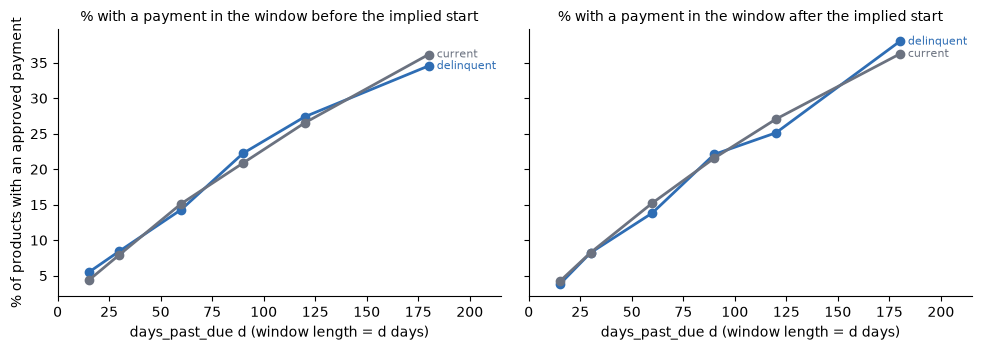

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for axis, period in zip(axes, ["before", "after"]):
    axis.plot(window_results.index, window_results[f"delinquent_{period}_pct"], "o-", color=BAR_COLOR, linewidth=2)
    axis.plot(window_results.index, window_results[f"current_{period}_pct"], "o-", color=MUTED_COLOR, linewidth=2)
    axis.text(window_results.index[-1] + 4, window_results[f"delinquent_{period}_pct"].iloc[-1], "delinquent", fontsize=8, color=BAR_COLOR, va="center")
    axis.text(window_results.index[-1] + 4, window_results[f"current_{period}_pct"].iloc[-1], "current", fontsize=8, color=MUTED_COLOR, va="center")
    axis.set_xlim(0, 215)
    axis.set_xlabel("days_past_due d (window length = d days)")
    axis.set_title(f"% with a payment in the window {period} the implied start", fontsize=10)
    axis.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("% of products with an approved payment")
plt.tight_layout()
plt.show()

## 6. Reliability of the payment data used here

In [10]:
payments_by_type = (
    approved_payments.merge(products[["product_code", "product_type"]], on="product_code")
    .groupby("product_type").size().to_frame("approved payments")
)
payments_by_type["share_pct"] = payments_by_type["approved payments"] / payments_by_type["approved payments"].sum() * 100
display(payments_by_type.sort_values("approved payments", ascending=False))
display(pd.Series({
    "products that ever received an approved payment": approved_payments["product_code"].nunique(),
    "of which non-credit products":
        (~pd.Index(approved_payments["product_code"].unique()).isin(credit["product_code"])).sum(),
    "current process memory, MB": current_memory_mb(),
}, name="value").to_frame())

,approved payments,share_pct
product_type,,
Tarjeta Crédito,152552,22.44
Cuenta Ahorro,122265,17.98
Préstamo Personal,121970,17.94
Cuenta Corriente,101524,14.93
Préstamo Hipotecario,72653,10.68
Tarjeta Débito,60520,8.90
Inversión,36005,5.30
Seguro,12465,1.83


,value
products that ever received an approved payment,"263,827.00"
of which non-credit products,"170,603.00"
"current process memory, MB",304.77


## 7. Conclusions

**Can `today - last payment date` reveal delinquency, or the payments made after it starts? No, not on
this data.**

**Data and cost.** 1,097 daily files (2023-06-17 to 2026-06-17, no missing days), 4,425,008
transactions, no duplicate `transaction_id`, every `product_id` known. Streaming one file at a time
kept the process at a peak of ~246 MB (about 57 MB above its 189 MB starting point) and ran in
under half a minute.

1. **Recency of the last payment does not track delinquency.** Median days since the last payment
   is 222-253 at every `days_past_due` level, the same as current products (238). The Spearman
   correlation is 0.00. The delinquency rate is 14.6-15.1% in every recency bucket (0-30 days
   through 366+), and 14.8% for products that never received a payment.
2. **Payments arrive at random, not as instalments.** The average gap between consecutive payments
   on the same credit product is 175 days. Only 5.5% of gaps fall within 25-35 days, which is what
   random arrivals with that average gap would give (5.3%); likewise 4.6% observed vs 4.5% expected
   within 55-65 days. There is no monthly rhythm to build "missed payment" logic on.
3. **Delinquent products pay as often as current ones during their supposed delinquency.** If a
   product were delinquent because payments stopped `d` days ago, its share with a payment in the
   last `d` days should be near zero. It is not, and it matches the current-product control:

   | days_past_due | Delinquent, paid in last `d` days | Current, same window |
   |---:|---:|---:|
   | 15 | 3.8% | 4.2% |
   | 30 | 8.2% | 8.3% |
   | 60 | 13.8% | 15.2% |
   | 90 | 22.1% | 21.6% |
   | 120 | 25.1% | 27.1% |
   | 180 | 38.0% | 36.2% |

   Comparing the window just before with the window after the implied start, delinquent products
   change by -1.7 (+/-1.1), -0.2, -0.5, -0.2, -2.3 (+/-2.3) and +3.4 (+/-2.5) percentage points for
   `d` = 15 ... 180, mixed in sign and unrelated to depth, while current products change by -0.1
   to +0.7. "Delinquency started when payments stopped" would predict a large fall in every row.
4. **`Payment` is not a credit repayment.** 170,603 of the 263,827 products that ever received an
   approved payment are not credit products (savings, checking, debit, investments, insurance), and
   128,092 payments (18.8%) are dated **before the product's `opening_date`**.

**Reliability notes.**

- Partitions follow the **business day** (process date, cutting over at 06:00), not the calendar
  day: 25% of rows carry a timestamp whose calendar date differs from their partition, yet only 51
  of 4.4 M rows break the rule `partition day = (timestamp - 6 h).date`. This is a convention, and
  it also corrects an earlier note that `process_date` looked "earlier" than the transaction date.
- "Implied delinquency start = snapshot date - `days_past_due`" assumes `days_past_due` counts
  continuous days as of the snapshot. If that is wrong the windows shift, but the recency and
  cadence results (1 and 2) do not depend on it.

**What this means.** Deriving delinquency from last-payment dates would be a reasonable method on
real data with a payments ledger tied to specific obligations (due date, amount due, payment date).
Here, payments and delinquency look generated independently, so the approach recovers nothing.
The bottleneck is unchanged: we need obligation-level payment records or repeated `days_past_due`
snapshots to define a genuine time-to-payment.